###Adaptive Conformal Prediction using Random Forest

---




In [ ]:
##########################################################################################################################################################################################################################################################################################################

In [1]:
!pip install lightgbm --quiet

In [2]:
!pip uninstall -y scikit-learn -q
!pip uninstall -y mapie -q

!pip install -q scikit-learn==1.3.2 mapie>=0.9.0

In [3]:
!pip install numpy



In [4]:
!pip install pandas

In [5]:
from mapie.regression import MapieQuantileRegressor

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 2. Build the full path to the CSV
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
#                ^^^^^^^^        ^^^^^^^^^^^^^^^  ^^^^
#                My Drive        folder shown     sub‑folder (RGP2)

# 3. Read it with pandas
import pandas as pd
data = pd.read_csv(csv_path)

# quick sanity‑check
data.head()

,Duration,Name,Date,Time,PA,NA,Som_neg,Self_esteem,Enj_act,Enj_social,Crave_Food,Crave_Other,In control,Concentrated,Worried,Impulsivity
0,260599,48216.0,2022-02-13,08:24:17,5.333333,1.000000,1.2,6.0,4.0,7.0,0.0,0.0,6.0,6.0,2.0,1.0
1,115305,48216.0,2022-02-13,09:55:51,5.333333,1.000000,1.0,5.0,4.5,7.0,0.0,0.0,6.0,6.0,1.0,1.0
2,811.56,48216.0,2022-02-13,11:20:21,5.666667,1.000000,1.2,5.5,5.5,7.0,0.0,0.0,1.0,7.0,1.0,1.0
3,143982,48216.0,2022-02-13,13:39:32,4.333333,1.333333,1.2,5.0,5.0,6.0,0.0,0.0,5.0,6.0,4.0,1.0
4,887725,48216.0,2022-02-13,14:56:31,3.666667,1.222222,1.2,5.5,6.0,6.0,0.0,0.0,1.0,6.0,1.0,1.0


In [ ]:
data

,Duration,Name,Date,Time,PA,NA,Som_neg,Self_esteem,Enj_act,Enj_social,Crave_Food,Crave_Other,In control,Concentrated,Worried,Impulsivity
0,260599,48216.0,2022-02-13,08:24:17,5.333333,1.000000,1.2,6.0,4.0,7.0,0.0,0.0,6.0,6.0,2.0,1.0
1,115305,48216.0,2022-02-13,09:55:51,5.333333,1.000000,1.0,5.0,4.5,7.0,0.0,0.0,6.0,6.0,1.0,1.0
2,811.56,48216.0,2022-02-13,11:20:21,5.666667,1.000000,1.2,5.5,5.5,7.0,0.0,0.0,1.0,7.0,1.0,1.0
3,143982,48216.0,2022-02-13,13:39:32,4.333333,1.333333,1.2,5.0,5.0,6.0,0.0,0.0,5.0,6.0,4.0,1.0
4,887725,48216.0,2022-02-13,14:56:31,3.666667,1.222222,1.2,5.5,6.0,6.0,0.0,0.0,1.0,6.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31286,123324,56132.0,2022-07-10,13:20:59,4.333333,2.111111,1.8,3.5,5.0,5.0,0.0,2.0,5.0,4.0,2.0,2.0
31287,112269,56132.0,2022-07-10,14:18:39,4.666667,1.777778,1.4,4.0,5.0,5.0,0.0,2.0,6.0,5.0,3.0,2.0
31288,104318,56132.0,2022-07-10,16:11:03,4.000000,1.777778,2.2,3.0,3.0,4.0,0.0,3.0,5.0,3.0,2.0,2.0
31289,438835,56132.0,2022-07-10,18:40:46,4.333333,2.000000,1.6,3.0,4.5,5.0,0.0,3.0,6.0,4.0,3.0,2.0


In [8]:
data['datetime'] = data['Date'] + ' ' + data['Time']
data['datetime'] = pd.to_datetime(data['datetime'])

In [9]:

# Sort by individual and time
data = data.sort_values(['Name', 'Time'])

# Add time features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

In [10]:
def add_time_and_lag_features(df, target, lags=[1,2,3]):
    df = df.copy()
    # Cyclical encoding for hour/dow
    df["hour_rad"] = 2 * np.pi * df["hour"] / 24
    df["dow_rad"]  = 2 * np.pi * df["day_of_week"]  / 7
    df["hour_sin"] = np.sin(df["hour_rad"])
    df["hour_cos"] = np.cos(df["hour_rad"])
    df["dow_sin"]  = np.sin(df["dow_rad"])
    df["dow_cos"]  = np.cos(df["dow_rad"])
    # Days since individual's first measurement
    df["days_since_start"] = (df["datetime"] - df.groupby("Name")["datetime"].transform("min")).dt.days

    # lag features for the target variable, per individual
    for lag in lags:
        df[f"{target}_lag{lag}"] = df.groupby("Name")[target].shift(lag)
    return df

### Locally Adaptive Decision Tree CP

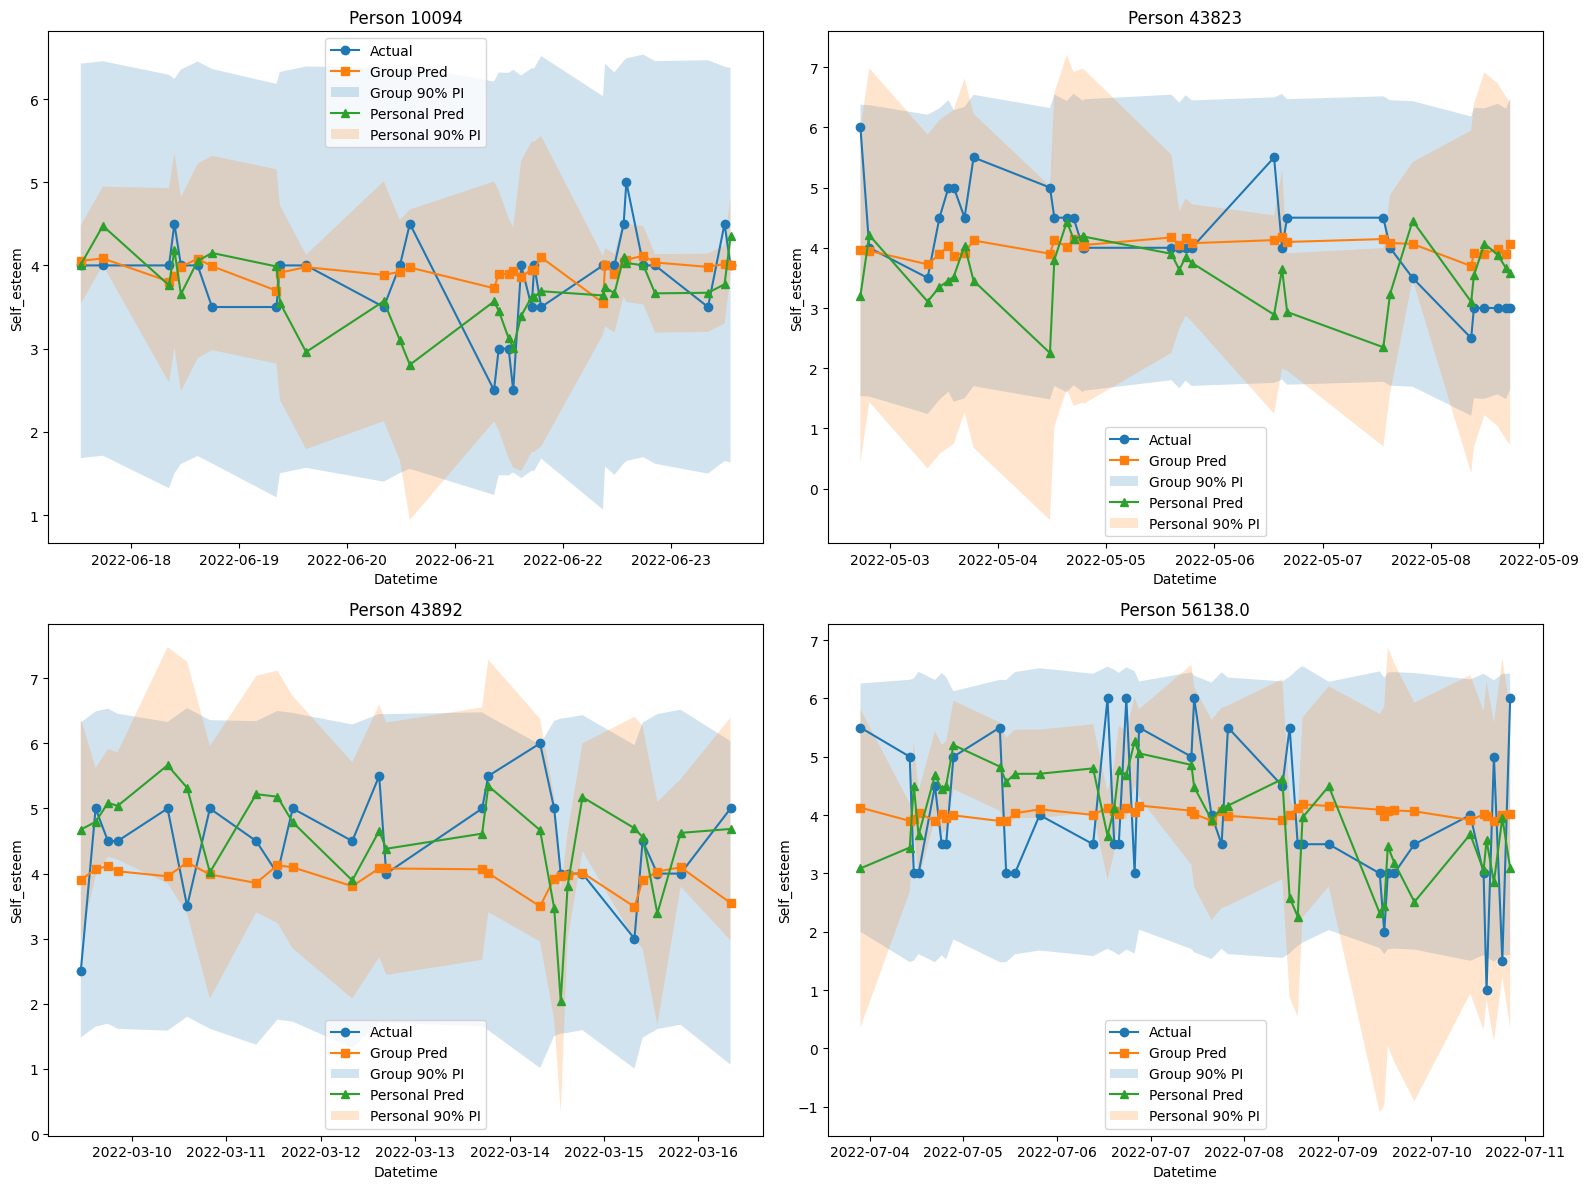

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import math

# --- 1) Load & feature-engineer ---
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# sort by Name then time
data = data.sort_values(['Name', 'datetime']).reset_index(drop=True)
# simple time features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

# define target and drop cols
target_col = 'Self_esteem'
all_targets = [
    'PA', 'NA', 'Som_neg', 'Self_esteem', 'Enj_act',
    'Enj_social', 'Crave_Food', 'Crave_Other', 'In control',
    'Concentrated', 'Worried', 'Impulsivity'
]
drop_cols = ['Date', 'Time']

# feature columns: numeric predictors except identifiers and all other targets
feature_cols = [
    c for c in data.columns
    if c not in drop_cols + all_targets + ['Name', 'datetime']
]
feature_cols = data[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# --- 2) Per-individual 60/20/20 split indices ---
train_idx, calib_idx, test_idx = [], [], []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    train_idx.extend(idx[:n_train])
    calib_idx.extend(idx[n_train:n_train + n_calib])
    test_idx.extend(idx[n_train + n_calib:])

# build DataFrames
train_df = data.loc[train_idx].sort_values(['Name','datetime'])
calib_df = data.loc[calib_idx].sort_values(['Name','datetime'])
test_df  = data.loc[test_idx].sort_values(['Name','datetime'])

# --- 3) Fit & calibrate global model ---
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_calib = calib_df[feature_cols]
y_calib = calib_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
rf_global.fit(X_train, y_train)

# calibration residuals
y_calib_pred = rf_global.predict(X_calib)
resid_calib = np.abs(y_calib - y_calib_pred)

# partition calibration set via small decision tree
tree_global = DecisionTreeRegressor(min_samples_leaf=15, max_leaf_nodes=5, random_state=42)
tree_global.fit(X_calib, resid_calib)
leaf_calib = tree_global.apply(X_calib)
leaf_test = tree_global.apply(X_test)

y_pred_g = rf_global.predict(X_test)
# compute pointwise 90% PI with leaf-specific quantiles
lower_g, upper_g = [], []
for i, leaf in enumerate(leaf_test):
    local_res = resid_calib[leaf_calib == leaf]
    if len(local_res) >= 5:
        q90 = np.quantile(local_res, 0.9)
    else:
        q90 = np.quantile(resid_calib, 0.9)
    lower_g.append(y_pred_g[i] - q90)
    upper_g.append(y_pred_g[i] + q90)

df_group = pd.DataFrame({
    'Name': test_df['Name'].values,
    'datetime': test_df['datetime'].values,
    'y_true': y_test.values,
    'y_pred': y_pred_g,
    'lower': lower_g,
    'upper': upper_g
})

# --- 4) Personalized models with same per-group splits ---
results_personal = []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    tr_idx = idx[:n_train]
    cl_idx = idx[n_train:n_train + n_calib]
    te_idx = idx[n_train + n_calib:]
    tr = data.loc[tr_idx]
    cl = data.loc[cl_idx]
    te = data.loc[te_idx]

    Xtr, ytr = tr[feature_cols], tr[target_col]
    Xcl, ycl = cl[feature_cols], cl[target_col]
    Xte, yte = te[feature_cols], te[target_col]

    rf_p = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_p.fit(Xtr, ytr)

    ycl_pred = rf_p.predict(Xcl)
    resid_p = np.abs(ycl - ycl_pred)

    tree_p = DecisionTreeRegressor(min_samples_leaf=5, max_leaf_nodes=4, random_state=42)
    tree_p.fit(Xcl, resid_p)
    leaf_cl = tree_p.apply(Xcl)
    leaf_te = tree_p.apply(Xte)

    y_pred_p = rf_p.predict(Xte)
    lower_p, upper_p = [], []
    for j, leaf in enumerate(leaf_te):
        local_res_p = resid_p[leaf_cl == leaf]
        if len(local_res_p) >= 3:
            q90p = np.quantile(local_res_p, 0.9)
        else:
            q90p = np.quantile(resid_p, 0.9)
        lower_p.append(y_pred_p[j] - q90p)
        upper_p.append(y_pred_p[j] + q90p)

    for dt, true, pred, lo, hi in zip(te['datetime'], yte, y_pred_p, lower_p, upper_p):
        results_personal.append({
            'Name': name,
            'datetime': dt,
            'y_true': true,
            'y_pred': pred,
            'lower': lo,
            'upper': hi
        })

df_personal = pd.DataFrame(results_personal)

# --- 5) Plot Group & Personalized Models for selected individuals ---
plot_ids = [10094, 43823, 43892, 56138.0]
n_show = len(plot_ids)
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten()

for i, pid in enumerate(plot_ids):
    ax = axes[i]
    # group
    gsub = df_group[df_group['Name'] == pid].sort_values('datetime')
    if not gsub.empty:
        ax.plot(gsub['datetime'], gsub['y_true'], 'o-', label='Actual')
        ax.plot(gsub['datetime'], gsub['y_pred'], 's-', label='Group Pred')
        ax.fill_between(gsub['datetime'], gsub['lower'], gsub['upper'], alpha=0.2, label='Group 90% PI')
    # personal
    psub = df_personal[df_personal['Name'] == pid].sort_values('datetime')
    if not psub.empty:
        ax.plot(psub['datetime'], psub['y_pred'], '^-', label='Personal Pred')
        ax.fill_between(psub['datetime'], psub['lower'], psub['upper'], alpha=0.2, label='Personal 90% PI')

    ax.set_title(f"Person {pid}")
    ax.set_xlabel('Datetime')
    ax.set_ylabel(target_col)
    ax.legend()

# remove unused axes
for ax in axes[n_show:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


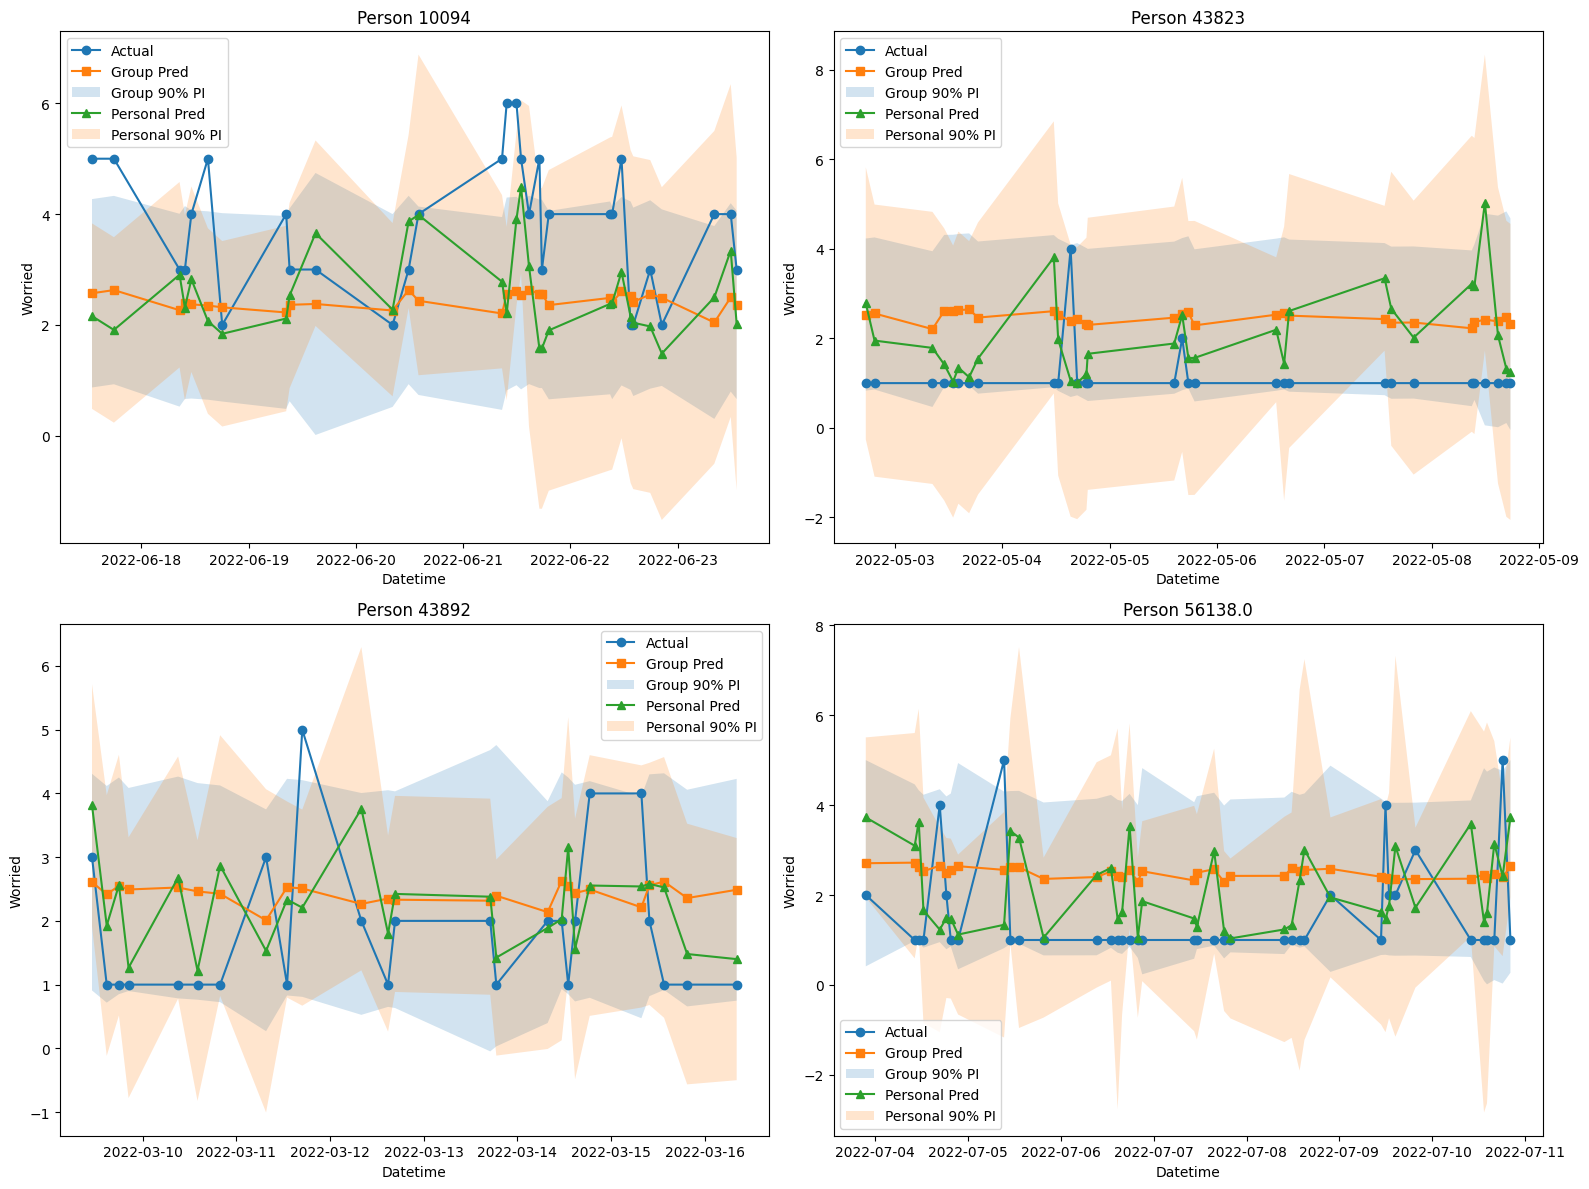

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import math

# --- 1) Load & feature-engineer ---
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# sort by Name then time
data = data.sort_values(['Name', 'datetime']).reset_index(drop=True)
# simple time features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

# define target and drop cols
target_col = 'Worried'
all_targets = [
    'PA', 'NA', 'Som_neg', 'Self_esteem', 'Enj_act',
    'Enj_social', 'Crave_Food', 'Crave_Other', 'In control',
    'Concentrated', 'Worried', 'Impulsivity'
]
drop_cols = ['Date', 'Time']

# feature columns: numeric predictors except identifiers and all other targets
feature_cols = [
    c for c in data.columns
    if c not in drop_cols + all_targets + ['Name', 'datetime']
]
feature_cols = data[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# --- 2) Per-individual 60/20/20 split indices ---
train_idx, calib_idx, test_idx = [], [], []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    train_idx.extend(idx[:n_train])
    calib_idx.extend(idx[n_train:n_train + n_calib])
    test_idx.extend(idx[n_train + n_calib:])

# build DataFrames
train_df = data.loc[train_idx].sort_values(['Name','datetime'])
calib_df = data.loc[calib_idx].sort_values(['Name','datetime'])
test_df  = data.loc[test_idx].sort_values(['Name','datetime'])

# --- 3) Fit & calibrate global model ---
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_calib = calib_df[feature_cols]
y_calib = calib_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
rf_global.fit(X_train, y_train)

# calibration residuals
y_calib_pred = rf_global.predict(X_calib)
resid_calib = np.abs(y_calib - y_calib_pred)

# partition calibration set via small decision tree
tree_global = DecisionTreeRegressor(min_samples_leaf=15, max_leaf_nodes=5, random_state=42)
tree_global.fit(X_calib, resid_calib)
leaf_calib = tree_global.apply(X_calib)
leaf_test = tree_global.apply(X_test)

y_pred_g = rf_global.predict(X_test)
# compute pointwise 90% PI with leaf-specific quantiles
lower_g, upper_g = [], []
for i, leaf in enumerate(leaf_test):
    local_res = resid_calib[leaf_calib == leaf]
    if len(local_res) >= 5:
        q90 = np.quantile(local_res, 0.9)
    else:
        q90 = np.quantile(resid_calib, 0.9)
    lower_g.append(y_pred_g[i] - q90)
    upper_g.append(y_pred_g[i] + q90)

df_group = pd.DataFrame({
    'Name': test_df['Name'].values,
    'datetime': test_df['datetime'].values,
    'y_true': y_test.values,
    'y_pred': y_pred_g,
    'lower': lower_g,
    'upper': upper_g
})

# --- 4) Personalized models with same per-group splits ---
results_personal = []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    tr_idx = idx[:n_train]
    cl_idx = idx[n_train:n_train + n_calib]
    te_idx = idx[n_train + n_calib:]
    tr = data.loc[tr_idx]
    cl = data.loc[cl_idx]
    te = data.loc[te_idx]

    Xtr, ytr = tr[feature_cols], tr[target_col]
    Xcl, ycl = cl[feature_cols], cl[target_col]
    Xte, yte = te[feature_cols], te[target_col]

    rf_p = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_p.fit(Xtr, ytr)

    ycl_pred = rf_p.predict(Xcl)
    resid_p = np.abs(ycl - ycl_pred)

    tree_p = DecisionTreeRegressor(min_samples_leaf=5, max_leaf_nodes=4, random_state=42)
    tree_p.fit(Xcl, resid_p)
    leaf_cl = tree_p.apply(Xcl)
    leaf_te = tree_p.apply(Xte)

    y_pred_p = rf_p.predict(Xte)
    lower_p, upper_p = [], []
    for j, leaf in enumerate(leaf_te):
        local_res_p = resid_p[leaf_cl == leaf]
        if len(local_res_p) >= 3:
            q90p = np.quantile(local_res_p, 0.9)
        else:
            q90p = np.quantile(resid_p, 0.9)
        lower_p.append(y_pred_p[j] - q90p)
        upper_p.append(y_pred_p[j] + q90p)

    for dt, true, pred, lo, hi in zip(te['datetime'], yte, y_pred_p, lower_p, upper_p):
        results_personal.append({
            'Name': name,
            'datetime': dt,
            'y_true': true,
            'y_pred': pred,
            'lower': lo,
            'upper': hi
        })

df_personal = pd.DataFrame(results_personal)

# --- 5) Plot Group & Personalized Models for selected individuals ---
plot_ids = [10094, 43823, 43892, 56138.0]
n_show = len(plot_ids)
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten()

for i, pid in enumerate(plot_ids):
    ax = axes[i]
    # group
    gsub = df_group[df_group['Name'] == pid].sort_values('datetime')
    if not gsub.empty:
        ax.plot(gsub['datetime'], gsub['y_true'], 'o-', label='Actual')
        ax.plot(gsub['datetime'], gsub['y_pred'], 's-', label='Group Pred')
        ax.fill_between(gsub['datetime'], gsub['lower'], gsub['upper'], alpha=0.2, label='Group 90% PI')
    # personal
    psub = df_personal[df_personal['Name'] == pid].sort_values('datetime')
    if not psub.empty:
        ax.plot(psub['datetime'], psub['y_pred'], '^-', label='Personal Pred')
        ax.fill_between(psub['datetime'], psub['lower'], psub['upper'], alpha=0.2, label='Personal 90% PI')

    ax.set_title(f"Person {pid}")
    ax.set_xlabel('Datetime')
    ax.set_ylabel(target_col)
    ax.legend()

# remove unused axes
for ax in axes[n_show:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


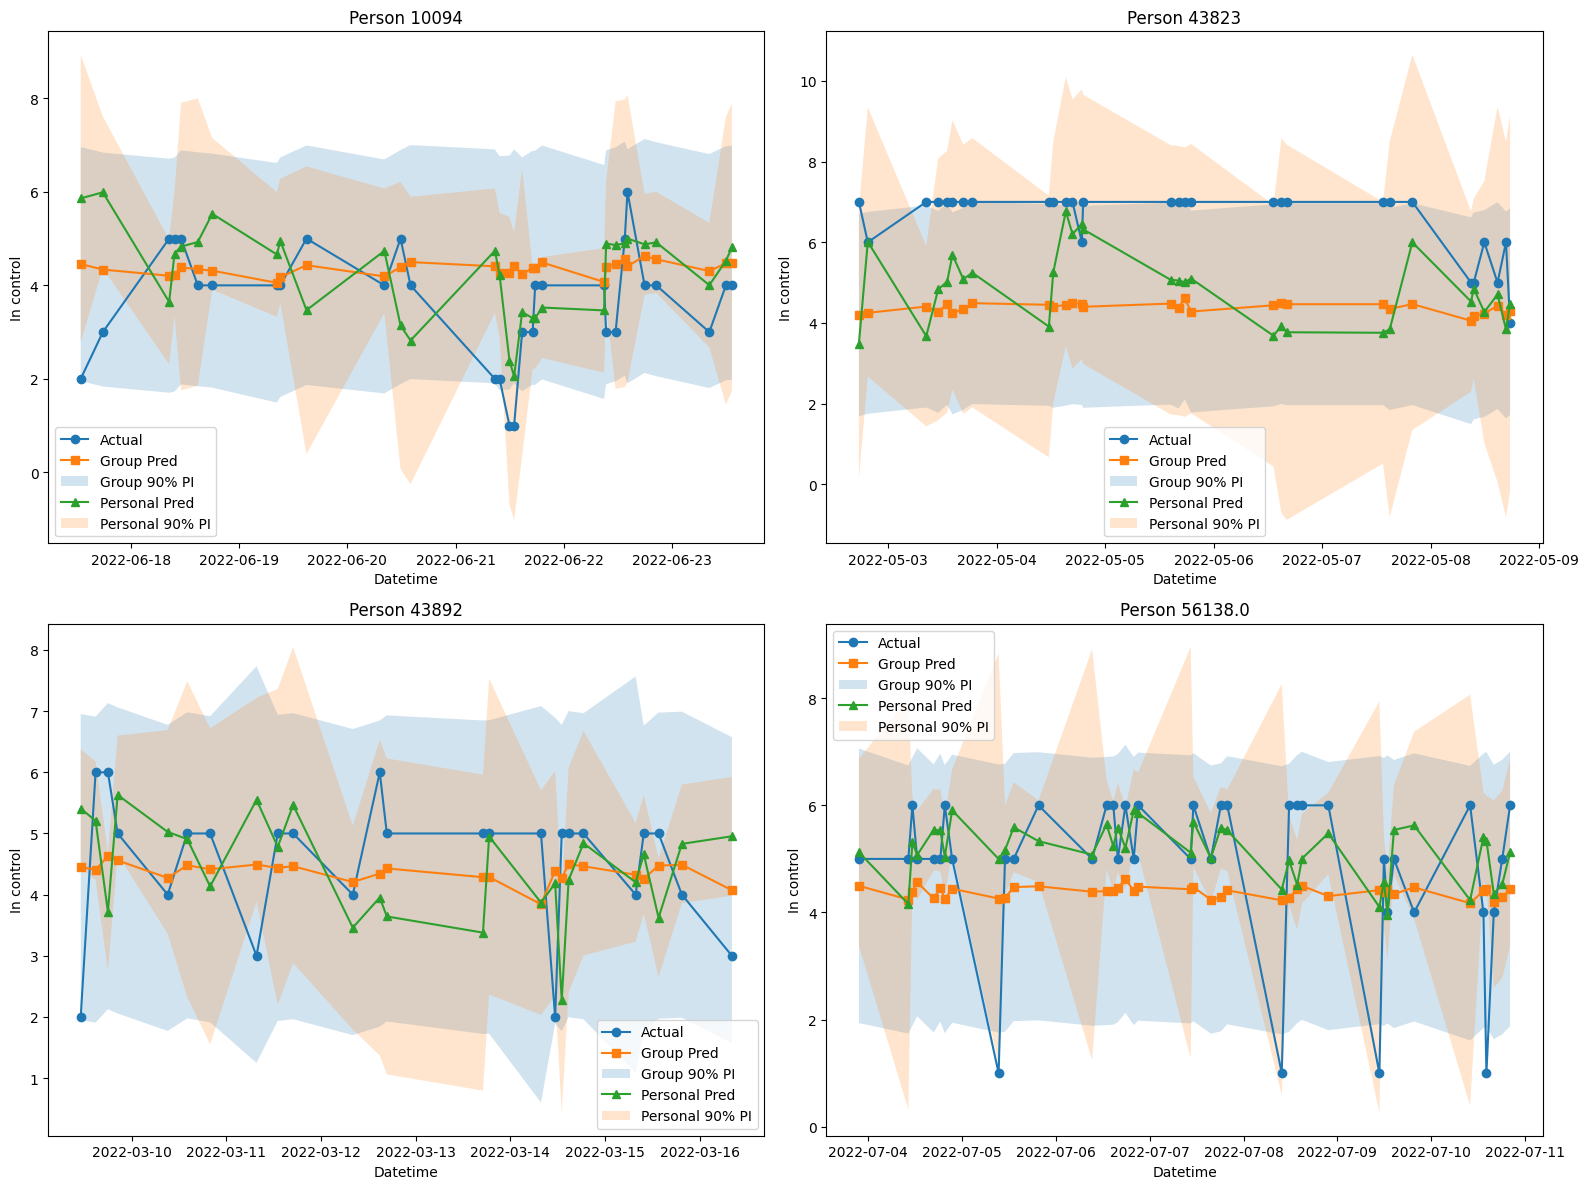

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import math

# --- 1) Load & feature-engineer ---
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])

# sort by Name then time
data = data.sort_values(['Name', 'datetime']).reset_index(drop=True)
# simple time features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

# define target and drop cols
target_col = 'In control'
all_targets = [
    'PA', 'NA', 'Som_neg', 'Self_esteem', 'Enj_act',
    'Enj_social', 'Crave_Food', 'Crave_Other', 'In control',
    'Concentrated', 'Worried', 'Impulsivity'
]
drop_cols = ['Date', 'Time']

# feature columns: numeric predictors except identifiers and all other targets
feature_cols = [
    c for c in data.columns
    if c not in drop_cols + all_targets + ['Name', 'datetime']
]
feature_cols = data[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# --- 2) Per-individual 60/20/20 split indices ---
train_idx, calib_idx, test_idx = [], [], []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    train_idx.extend(idx[:n_train])
    calib_idx.extend(idx[n_train:n_train + n_calib])
    test_idx.extend(idx[n_train + n_calib:])

# build DataFrames
train_df = data.loc[train_idx].sort_values(['Name','datetime'])
calib_df = data.loc[calib_idx].sort_values(['Name','datetime'])
test_df  = data.loc[test_idx].sort_values(['Name','datetime'])

# --- 3) Fit & calibrate global model ---
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_calib = calib_df[feature_cols]
y_calib = calib_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
rf_global.fit(X_train, y_train)

# calibration residuals
y_calib_pred = rf_global.predict(X_calib)
resid_calib = np.abs(y_calib - y_calib_pred)

# partition calibration set via small decision tree
tree_global = DecisionTreeRegressor(min_samples_leaf=15, max_leaf_nodes=5, random_state=42)
tree_global.fit(X_calib, resid_calib)
leaf_calib = tree_global.apply(X_calib)
leaf_test = tree_global.apply(X_test)

y_pred_g = rf_global.predict(X_test)
# compute pointwise 90% PI with leaf-specific quantiles
lower_g, upper_g = [], []
for i, leaf in enumerate(leaf_test):
    local_res = resid_calib[leaf_calib == leaf]
    if len(local_res) >= 5:
        q90 = np.quantile(local_res, 0.9)
    else:
        q90 = np.quantile(resid_calib, 0.9)
    lower_g.append(y_pred_g[i] - q90)
    upper_g.append(y_pred_g[i] + q90)

df_group = pd.DataFrame({
    'Name': test_df['Name'].values,
    'datetime': test_df['datetime'].values,
    'y_true': y_test.values,
    'y_pred': y_pred_g,
    'lower': lower_g,
    'upper': upper_g
})

# --- 4) Personalized models with same per-group splits ---
results_personal = []
for name, grp in data.groupby('Name'):
    grp = grp.sort_values('datetime')
    idx = grp.index.values
    m = len(idx)
    n_train = math.floor(0.6 * m)
    n_calib = math.floor(0.2 * m)
    tr_idx = idx[:n_train]
    cl_idx = idx[n_train:n_train + n_calib]
    te_idx = idx[n_train + n_calib:]
    tr = data.loc[tr_idx]
    cl = data.loc[cl_idx]
    te = data.loc[te_idx]

    Xtr, ytr = tr[feature_cols], tr[target_col]
    Xcl, ycl = cl[feature_cols], cl[target_col]
    Xte, yte = te[feature_cols], te[target_col]

    rf_p = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_p.fit(Xtr, ytr)

    ycl_pred = rf_p.predict(Xcl)
    resid_p = np.abs(ycl - ycl_pred)

    tree_p = DecisionTreeRegressor(min_samples_leaf=5, max_leaf_nodes=4, random_state=42)
    tree_p.fit(Xcl, resid_p)
    leaf_cl = tree_p.apply(Xcl)
    leaf_te = tree_p.apply(Xte)

    y_pred_p = rf_p.predict(Xte)
    lower_p, upper_p = [], []
    for j, leaf in enumerate(leaf_te):
        local_res_p = resid_p[leaf_cl == leaf]
        if len(local_res_p) >= 3:
            q90p = np.quantile(local_res_p, 0.9)
        else:
            q90p = np.quantile(resid_p, 0.9)
        lower_p.append(y_pred_p[j] - q90p)
        upper_p.append(y_pred_p[j] + q90p)

    for dt, true, pred, lo, hi in zip(te['datetime'], yte, y_pred_p, lower_p, upper_p):
        results_personal.append({
            'Name': name,
            'datetime': dt,
            'y_true': true,
            'y_pred': pred,
            'lower': lo,
            'upper': hi
        })

df_personal = pd.DataFrame(results_personal)

# --- 5) Plot Group & Personalized Models for selected individuals ---
plot_ids = [10094, 43823, 43892, 56138.0]
n_show = len(plot_ids)
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten()

for i, pid in enumerate(plot_ids):
    ax = axes[i]
    # group
    gsub = df_group[df_group['Name'] == pid].sort_values('datetime')
    if not gsub.empty:
        ax.plot(gsub['datetime'], gsub['y_true'], 'o-', label='Actual')
        ax.plot(gsub['datetime'], gsub['y_pred'], 's-', label='Group Pred')
        ax.fill_between(gsub['datetime'], gsub['lower'], gsub['upper'], alpha=0.2, label='Group 90% PI')
    # personal
    psub = df_personal[df_personal['Name'] == pid].sort_values('datetime')
    if not psub.empty:
        ax.plot(psub['datetime'], psub['y_pred'], '^-', label='Personal Pred')
        ax.fill_between(psub['datetime'], psub['lower'], psub['upper'], alpha=0.2, label='Personal 90% PI')

    ax.set_title(f"Person {pid}")
    ax.set_xlabel('Datetime')
    ax.set_ylabel(target_col)
    ax.legend()

# remove unused axes
for ax in axes[n_show:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### "Enbpi" Personalized Mapie Time Series Adaptive CP

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


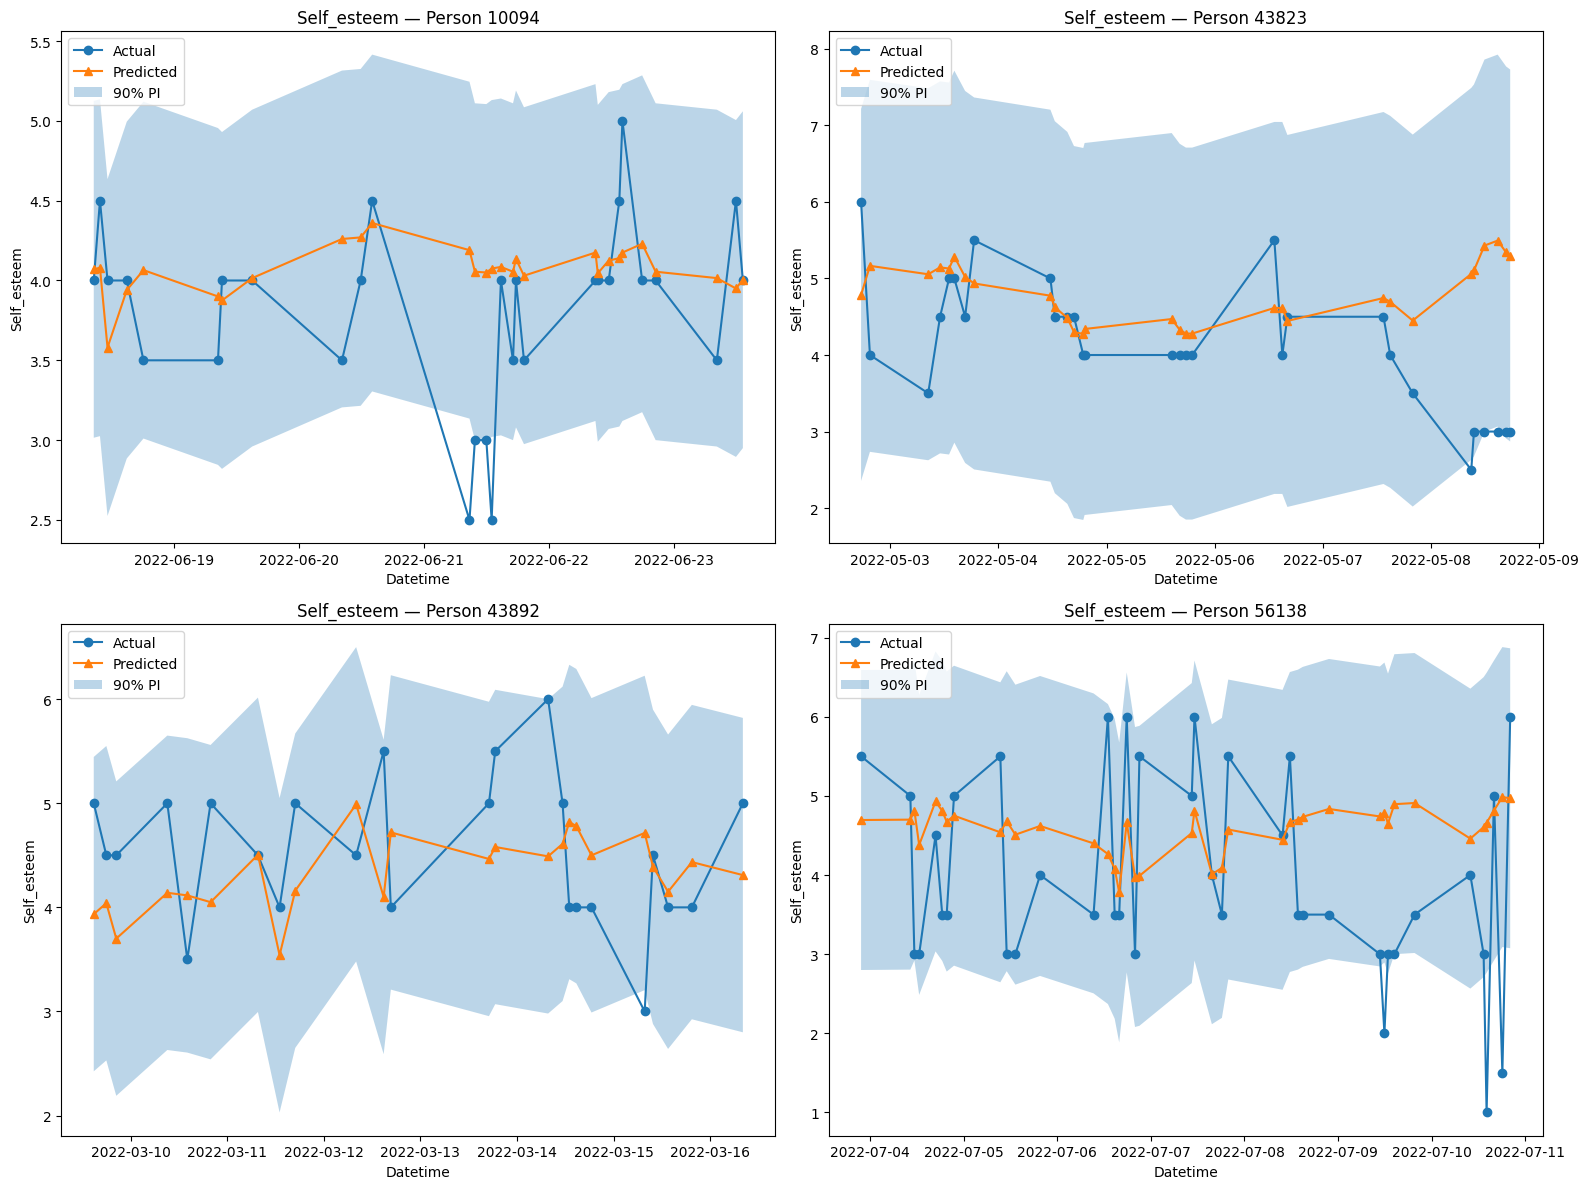

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from mapie.regression import MapieTimeSeriesRegressor as TimeSeriesRegressor
from mapie.conformity_scores import AbsoluteConformityScore
from sklearn.model_selection import PredefinedSplit
from google.colab import drive
import math

# Feature Engineering
def add_time_and_lag_features(df, target, lags=[1,2,3]):
    df2 = df.copy()
    df2["hour_rad"] = 2 * np.pi * df2["hour"] / 24
    df2["dow_rad"]  = 2 * np.pi * df2["day_of_week"] / 7
    df2["hour_sin"] = np.sin(df2["hour_rad"])
    df2["hour_cos"] = np.cos(df2["hour_rad"])
    df2["dow_sin"]  = np.sin(df2["dow_rad"])
    df2["dow_cos"]  = np.cos(df2["dow_rad"])
    df2["days_since_start"] = (df2["datetime"] -
                               df2.groupby("Name")["datetime"].transform("min")).dt.days
    for l in lags:
        df2[f"{target}_lag{l}"] = df2.groupby("Name")[target].shift(l)
    return df2

# Load Data
drive.mount('/content/drive')
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])
data = data.sort_values(['Name', 'datetime'])
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

all_targets = [
    'PA', 'NA', 'Som_neg', 'Self_esteem', 'Enj_act',
    'Enj_social', 'Crave_Food', 'Crave_Other', 'In control',
    'Concentrated', 'Worried', 'Impulsivity'
]
target_col = 'Self_esteem'

# Feature Engineering
data_feat = add_time_and_lag_features(data, target_col, lags=[1,2,3])
data_feat = data_feat.dropna(subset=[f"{target_col}_lag{l}" for l in [1,2,3]])

# Feature Selection
drop_cols = [c for c in all_targets if c != target_col] + ['Name', 'Date', 'Time', 'datetime']
feature_cols = [
    c for c in data_feat.columns
    if c not in drop_cols + ['hour', 'day_of_week', 'hour_rad', 'dow_rad'] and c != target_col
]

X = data_feat[feature_cols].select_dtypes(include=[np.number])
y = data_feat[target_col]

# Group Model Split (60/20/20)
n = len(X)
n_train = int(0.6 * n)
n_calib = int(0.2 * n)
n_test = n - n_train - n_calib

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_calib, y_calib = X.iloc[n_train:n_train+n_calib], y.iloc[n_train:n_train+n_calib]
X_test, y_test = X.iloc[n_train+n_calib:], y.iloc[n_train+n_calib:]

# PredefinedSplit for EnbPi (calib/test only)
n_val = n_calib + n_test
cv_mapiets = PredefinedSplit([-1]*n_calib + [0]*n_test)

X_aci = pd.concat([X_calib, X_test])
y_aci = pd.concat([y_calib, y_test])

# # GROUP-BASED EnbPi (MAPIE, ENBPI)
# model = RandomForestRegressor(n_estimators=100, random_state=1)
# enbppi = TimeSeriesRegressor(
#     estimator=model,
#     method="enbpi",
#     agg_function="mean",
#     cv=cv_mapiets,
#     n_jobs=-1,
#     conformity_score=AbsoluteConformityScore(sym=True)
# )
# enbppi.fit(X_aci, y_aci)
# y_pred, y_pis = enbppi.predict(X_aci, alpha=0.1)
# lower = y_pis[:, 0, 0]
# upper = y_pis[:, 1, 0]

# # Save group-based results for plotting by individual
# df_group = pd.DataFrame({
#     "Name": data_feat.iloc[n_train+n_calib:]["Name"].values,
#     "datetime": data_feat.iloc[n_train+n_calib:]["datetime"].values,
#     "y_true": y_test.values,
#     "y_pred": y_pred[-n_test:],  # last n_test predictions
#     "lower": lower[-n_test:],
#     "upper": upper[-n_test:]
# })

# PERSONALIZED ACI: Each person, their own model/split
results_personal = []
for name, group in data_feat.groupby("Name"):
    group = group.sort_values("datetime")
    Xp = group[feature_cols].select_dtypes(include=[np.number])
    yp = group[target_col]
    n_p = len(Xp)
    n_train_p = int(0.6 * n_p)
    n_calib_p = int(0.2 * n_p)
    n_test_p = n_p - n_train_p - n_calib_p
    if n_p < 15 or n_test_p < 2:
        continue
    X_train_p = Xp.iloc[:n_train_p]
    y_train_p = yp.iloc[:n_train_p]
    X_calib_p = Xp.iloc[n_train_p:n_train_p+n_calib_p]
    y_calib_p = yp.iloc[n_train_p:n_train_p+n_calib_p]
    X_test_p = Xp.iloc[n_train_p+n_calib_p:]
    y_test_p = yp.iloc[n_train_p+n_calib_p:]

    # PredefinedSplit for this person
    X_aci_p = pd.concat([X_calib_p, X_test_p])
    y_aci_p = pd.concat([y_calib_p, y_test_p])
    n_val_p = n_calib_p + n_test_p
    cv_mapiets_p = PredefinedSplit([-1]*n_calib_p + [0]*n_test_p)

    try:
        model_p = RandomForestRegressor(n_estimators=100, random_state=1)
        enbppi_p = TimeSeriesRegressor(
            estimator=model_p,
            method="enbpi",
            agg_function="mean",
            cv=cv_mapiets_p,
            n_jobs=-1,
            conformity_score=AbsoluteConformityScore(sym=True)
        )
        enbppi_p.fit(X_aci_p, y_aci_p)
        y_pred_p, y_pis_p = enbppi_p.predict(X_aci_p, alpha=0.1)
        lower_p = y_pis_p[:, 0, 0]
        upper_p = y_pis_p[:, 1, 0]
        results_personal.append(pd.DataFrame({
            "Name": name,
            "datetime": group.iloc[n_train_p+n_calib_p:]["datetime"].values,
            "y_true": y_test_p.values,
            "y_pred": y_pred_p[-n_test_p:],
            "lower": lower_p[-n_test_p:],
            "upper": upper_p[-n_test_p:]
        }))
    except Exception as e:
        continue

df_personal = pd.concat(results_personal, ignore_index=True)

import math

# test_users = df_group["Name"].unique()  # Use test set users from group model
# n_show = 6
# n_cols = 2
# n_rows = math.ceil(n_show / n_cols)

# # Plot Group Model
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
# axes = axes.flatten()
# for i, pid in enumerate(test_users[:n_show]):
#     ax = axes[i]
#     sub_group = df_group[df_group["Name"] == pid].sort_values("datetime")
#     ax.plot(sub_group["datetime"], sub_group["y_true"], "o-", color='C0', label="Actual")
#     ax.plot(sub_group["datetime"], sub_group["y_pred"], "s-", color='C1', label="Group Predicted")
#     ax.fill_between(sub_group["datetime"], sub_group["lower"], sub_group["upper"], color='C1', alpha=0.2, label="Group 90% PI")
#     ax.set_title(f"{target_col} (Group Model)\nPerson {pid}")
#     ax.set_xlabel("Time")
#     ax.set_ylabel(target_col)
#     ax.grid(True)
#     if i == 0: ax.legend()
# for ax in axes[len(test_users[:n_show]):]:
#     fig.delaxes(ax)
# plt.tight_layout()
# plt.show()

# # Plot Personalized Model
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
# axes = axes.flatten()
# for i, pid in enumerate(test_users[:n_show]):
#     ax = axes[i]
#     sub_person = df_personal[df_personal["Name"] == pid].sort_values("datetime")
#     if not sub_person.empty:
#         ax.plot(sub_person["datetime"], sub_person["y_true"], "o-", color='C0', label="Actual")
#         ax.plot(sub_person["datetime"], sub_person["y_pred"], "^-", color='C2', label="Personalized Predicted")
#         ax.fill_between(sub_person["datetime"], sub_person["lower"], sub_person["upper"], color='C2', alpha=0.2, label="Personalized 90% PI")
#     ax.set_title(f"{target_col} (Personalized)\nPerson {pid}")
#     ax.set_xlabel("Time")
#     ax.set_ylabel(target_col)
#     ax.grid(True)
#     if i == 0: ax.legend()
# for ax in axes[len(test_users[:n_show]):]:
#     fig.delaxes(ax)
# plt.tight_layout()
# plt.show()

import matplotlib.pyplot as plt
import math

# list the IDs you want to see
plot_ids = [10094, 43823, 43892, 56138.0]

n_show = len(plot_ids)
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows), sharex=False)
axes = axes.flatten()

for ax, pid in zip(axes, plot_ids):
    sub = df_personal[df_personal["Name"] == pid].sort_values("datetime")
    if not sub.empty:
        ax.plot(sub["datetime"], sub["y_true"], "o-", label="Actual")
        ax.plot(sub["datetime"], sub["y_pred"], "^-", label="Predicted")
        ax.fill_between(sub["datetime"], sub["lower"], sub["upper"],
                        alpha=0.3, label="90% PI")
    ax.set_title(f"{target_col} — Person {int(pid)}")
    ax.set_xlabel("Datetime")
    ax.set_ylabel(target_col)
    ax.legend(loc="upper left")

# drop any unused axes
for ax in axes[n_show:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Custom EnbPI Adaptive CP

---




In [15]:
import numpy as np
from sklearn.utils import resample
from sklearn.base import clone

class EnbPI:
    def __init__(self, base_model, alpha=0.1, B=30, random_state=42):
        self.base_model = base_model
        self.alpha = alpha
        self.B = B
        self.random_state = random_state
        self.boot_models = []
        self.is_fitted = False

    def fit(self, X_train, y_train):
        self.boot_models = []
        np.random.seed(self.random_state)
        for b in range(self.B):
            idx = resample(range(len(X_train)), replace=True, random_state=self.random_state+b)
            Xb, yb = X_train.iloc[idx], y_train.iloc[idx]
            model = clone(self.base_model)
            model.fit(Xb, yb)
            self.boot_models.append(model)
        self.is_fitted = True

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("You must fit() before predict().")
        preds = np.array([model.predict(X) for model in self.boot_models])
        self.preds = preds
        return np.mean(preds, axis=0)

    def calibrate(self, X_calib, y_calib):
        pred_calib = np.array([model.predict(X_calib) for model in self.boot_models])
        pred_mean = np.mean(pred_calib, axis=0)
        self.residuals = np.abs(y_calib - pred_mean)
        self.qhat = np.quantile(self.residuals, 1-self.alpha)
        self.calibrated = True

    def predict_interval(self, X):
        if not hasattr(self, "calibrated") or not self.calibrated:
            raise ValueError("You must calibrate() before predict_interval().")
        pred_mean = self.predict(X)
        lower = pred_mean - self.qhat
        upper = pred_mean + self.qhat
        return pred_mean, lower, upper


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import resample
from sklearn.base import clone
import matplotlib.pyplot as plt
import math



# Feature Engineering
def add_time_and_lag_features(df, target, lags=[1,2,3]):
    df2 = df.copy()
    df2["hour_rad"] = 2 * np.pi * df2["hour"] / 24
    df2["dow_rad"]  = 2 * np.pi * df2["day_of_week"] / 7
    df2["hour_sin"] = np.sin(df2["hour_rad"])
    df2["hour_cos"] = np.cos(df2["hour_rad"])
    df2["dow_sin"]  = np.sin(df2["dow_rad"])
    df2["dow_cos"]  = np.cos(df2["dow_rad"])
    df2["days_since_start"] = (df2["datetime"] -
                               df2.groupby("Name")["datetime"].transform("min")).dt.days
    for l in lags:
        df2[f"{target}_lag{l}"] = df2.groupby("Name")[target].shift(l)
    return df2

#  Load Data
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])
data = data.sort_values(['Name', 'datetime'])
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

all_targets = [
    'PA', 'NA', 'Som_neg', 'Self_esteem', 'Enj_act',
    'Enj_social', 'Crave_Food', 'Crave_Other', 'In control',
    'Concentrated', 'Worried', 'Impulsivity'
]
target_col = 'Self_esteem'

# Feature Engineering
data_feat = add_time_and_lag_features(data, target_col, lags=[1,2,3])
data_feat = data_feat.dropna(subset=[f"{target_col}_lag{l}" for l in [1,2,3]])

drop_cols = [c for c in all_targets if c != target_col] + ['Name', 'Date', 'Time', 'datetime']
feature_cols = [
    c for c in data_feat.columns
    if c not in drop_cols + ['hour', 'day_of_week', 'hour_rad', 'dow_rad'] and c != target_col
]

# GROUP-BASED EnbPI
X = data_feat[feature_cols].select_dtypes(include=[np.number])
y = data_feat[target_col]

n = len(X)
n_train = int(0.6 * n)
n_calib = int(0.2 * n)
n_test = n - n_train - n_calib

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_calib, y_calib = X.iloc[n_train:n_train+n_calib], y.iloc[n_train:n_train+n_calib]
X_test, y_test = X.iloc[n_train+n_calib:], y.iloc[n_train+n_calib:]
test_names = data_feat.iloc[n_train+n_calib:]['Name'].values
test_dt = data_feat.iloc[n_train+n_calib:]['datetime'].values

base_model = RandomForestRegressor(n_estimators=100, random_state=0)
enbpi = EnbPI(base_model=base_model, alpha=0.1, B=30, random_state=42)

enbpi.fit(X_train, y_train)
enbpi.calibrate(X_calib, y_calib)
y_pred, lower, upper = enbpi.predict_interval(X_test)

df_group = pd.DataFrame({
    "Name": test_names,
    "datetime": test_dt,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "lower": lower,
    "upper": upper
})

# PERSONALIZED EnbPI
results = []
for name, group in data_feat.groupby("Name"):
    group = group.sort_values("datetime")
    Xp = group[feature_cols].select_dtypes(include=[np.number])
    yp = group[target_col]
    n_p = len(Xp)
    n_train_p = int(0.6 * n_p)
    n_calib_p = int(0.2 * n_p)
    if n_p < 12 or (n_p - n_train_p - n_calib_p) < 2:
        continue
    X_train_p = Xp.iloc[:n_train_p]
    y_train_p = yp.iloc[:n_train_p]
    X_calib_p = Xp.iloc[n_train_p:n_train_p+n_calib_p]
    y_calib_p = yp.iloc[n_train_p:n_train_p+n_calib_p]
    X_test_p = Xp.iloc[n_train_p+n_calib_p:]
    y_test_p = yp.iloc[n_train_p+n_calib_p:]
    dt_test_p = group.iloc[n_train_p+n_calib_p:]["datetime"].values

    enbpi_p = EnbPI(base_model=RandomForestRegressor(n_estimators=100, random_state=1),
                    alpha=0.1, B=30, random_state=42)
    enbpi_p.fit(X_train_p, y_train_p)
    enbpi_p.calibrate(X_calib_p, y_calib_p)
    y_pred_p, lower_p, upper_p = enbpi_p.predict_interval(X_test_p)
    results.append(pd.DataFrame({
        "Name": name,
        "datetime": dt_test_p,
        "y_true": y_test_p.values,
        "y_pred": y_pred_p,
        "lower": lower_p,
        "upper": upper_p
    }))

df_personal = pd.concat(results, ignore_index=True)
# Choose the four people we want to visualize
plot_ids = [10094, 43823, 43892, 56138.0]

# Grid dimensions
n_show = len(plot_ids)
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

# --- Plot Group‐based EnbPI ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows), sharex=False)
axes = axes.flatten()
for ax, pid in zip(axes, plot_ids):
    sub = df_group[df_group["Name"] == pid].sort_values("datetime")
    if not sub.empty:
        ax.plot(sub["datetime"], sub["y_true"], "o-", color='C0', label="Actual")
        ax.plot(sub["datetime"], sub["y_pred"], "s-", color='C1', label="Group Pred")
        ax.fill_between(sub["datetime"], sub["lower"], sub["upper"],
                        color='C1', alpha=0.2, label="Group 90% PI")
    ax.set_title(f"{target_col} (Group Model)\nPerson {int(pid)}")
    ax.set_xlabel("Time")
    ax.set_ylabel(target_col)
    ax.legend()
for ax in axes[n_show:]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()

# --- Plot Personalized EnbPI ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows), sharex=False)
axes = axes.flatten()
for ax, pid in zip(axes, plot_ids):
    sub = df_personal[df_personal["Name"] == pid].sort_values("datetime")
    if not sub.empty:
        ax.plot(sub["datetime"], sub["y_true"], "o-", color='C0', label="Actual")
        ax.plot(sub["datetime"], sub["y_pred"], "^-", color='C2', label="Personal Pred")
        ax.fill_between(sub["datetime"], sub["lower"], sub["upper"],
                        color='C2', alpha=0.2, label="Personal 90% PI")
    ax.set_title(f"{target_col} (Personalized)\nPerson {int(pid)}")
    ax.set_xlabel("Time")
    ax.set_ylabel(target_col)
    ax.legend()
for ax in axes[n_show:]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()

# # PLOTTING (Group vs. Personalized)
# import math
# test_users = df_group["Name"].unique()
# n_show = 6
# n_cols = 2
# n_rows = math.ceil(n_show / n_cols)

# # Plot Group Model
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
# axes = axes.flatten()
# for i, pid in enumerate(test_users[:n_show]):
#     ax = axes[i]
#     sub_group = df_group[df_group["Name"] == pid].sort_values("datetime")
#     ax.plot(sub_group["datetime"], sub_group["y_true"], "o-", color='C0', label="Actual")
#     ax.plot(sub_group["datetime"], sub_group["y_pred"], "s-", color='C1', label="Group Predicted")
#     ax.fill_between(sub_group["datetime"], sub_group["lower"], sub_group["upper"], color='C1', alpha=0.2, label="Group 90% PI")
#     ax.set_title(f"{target_col} (Group Model)\nPerson {pid}")
#     ax.set_xlabel("Time")
#     ax.set_ylabel(target_col)
#     ax.grid(True)
#     if i == 0: ax.legend()
# for ax in axes[len(test_users[:n_show]):]:
#     fig.delaxes(ax)
# plt.tight_layout()
# plt.show()

# # Plot Personalized Model
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
# axes = axes.flatten()
# for i, pid in enumerate(test_users[:n_show]):
#     ax = axes[i]
#     sub_person = df_personal[df_personal["Name"] == pid].sort_values("datetime")
#     if not sub_person.empty:
#         ax.plot(sub_person["datetime"], sub_person["y_true"], "o-", color='C0', label="Actual")
#         ax.plot(sub_person["datetime"], sub_person["y_pred"], "^-", color='C2', label="Personalized Predicted")
#         ax.fill_between(sub_person["datetime"], sub_person["lower"], sub_person["upper"], color='C2', alpha=0.2, label="Personalized 90% PI")
#     ax.set_title(f"{target_col} (Personalized)\nPerson {pid}")
#     ax.set_xlabel("Time")
#     ax.set_ylabel(target_col)
#     ax.grid(True)
#     if i == 0: ax.legend()
# for ax in axes[len(test_users[:n_show]):]:
#     fig.delaxes(ax)
# plt.tight_layout()
# plt.show()

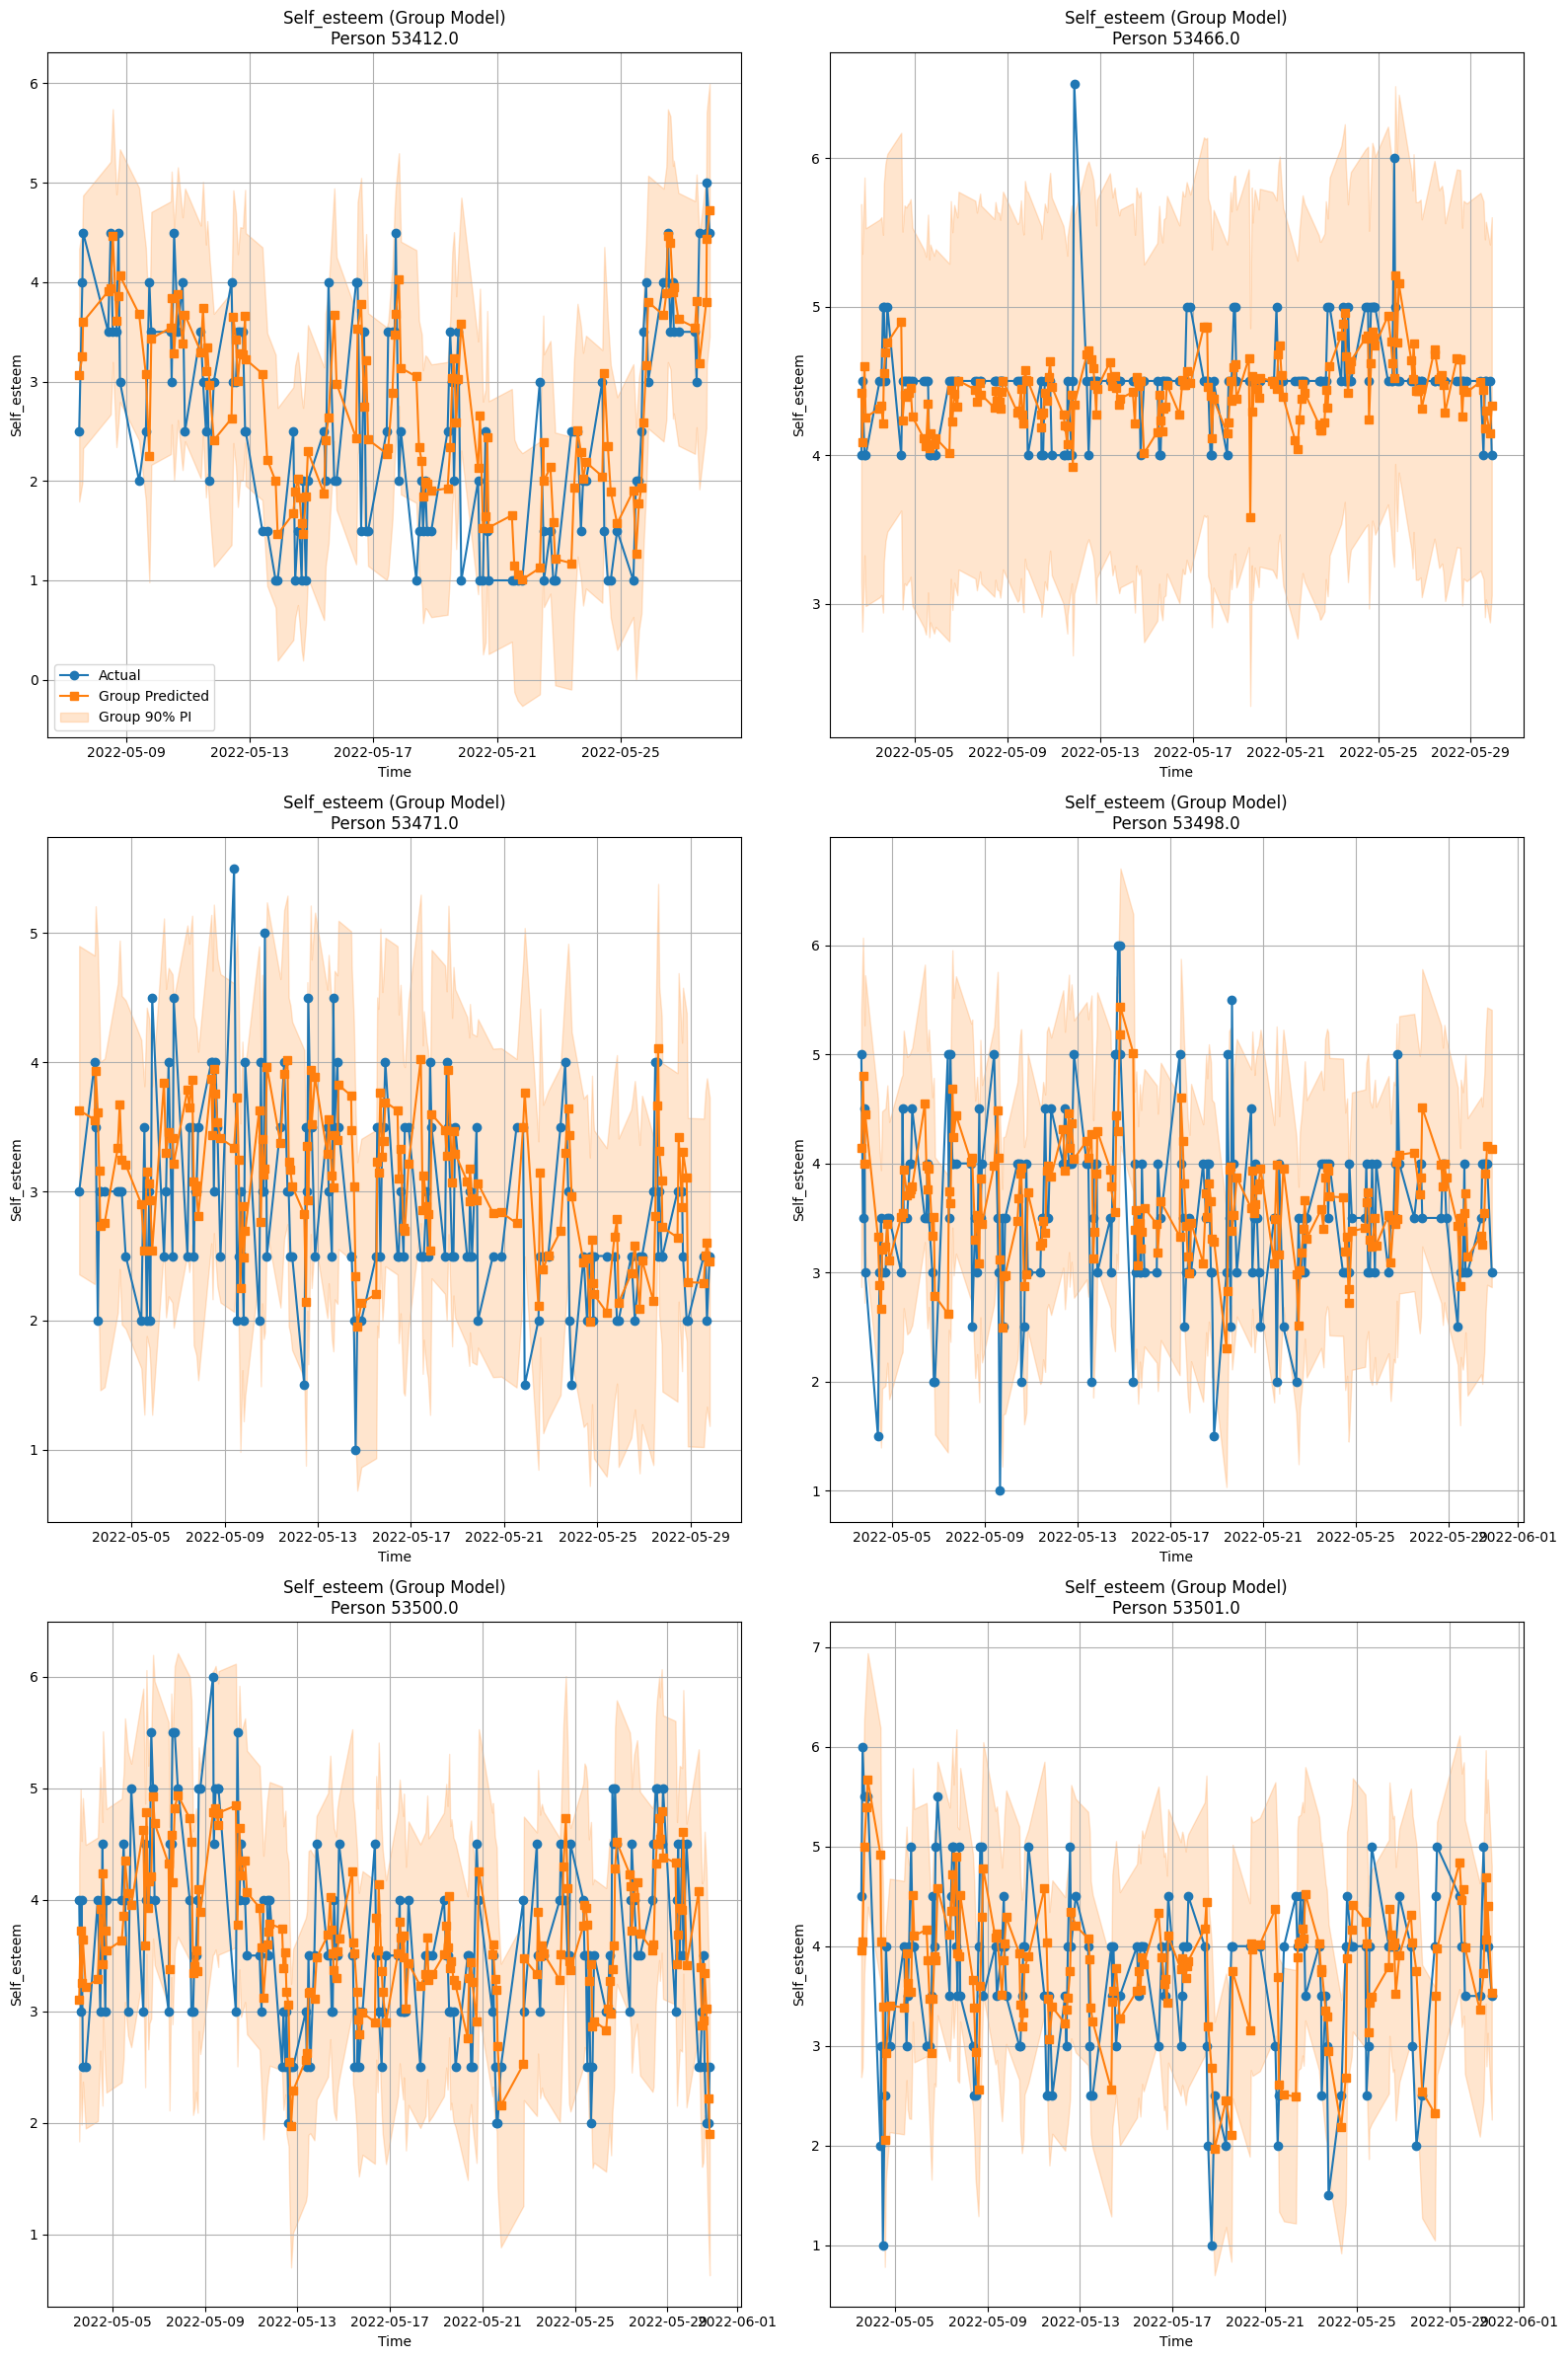

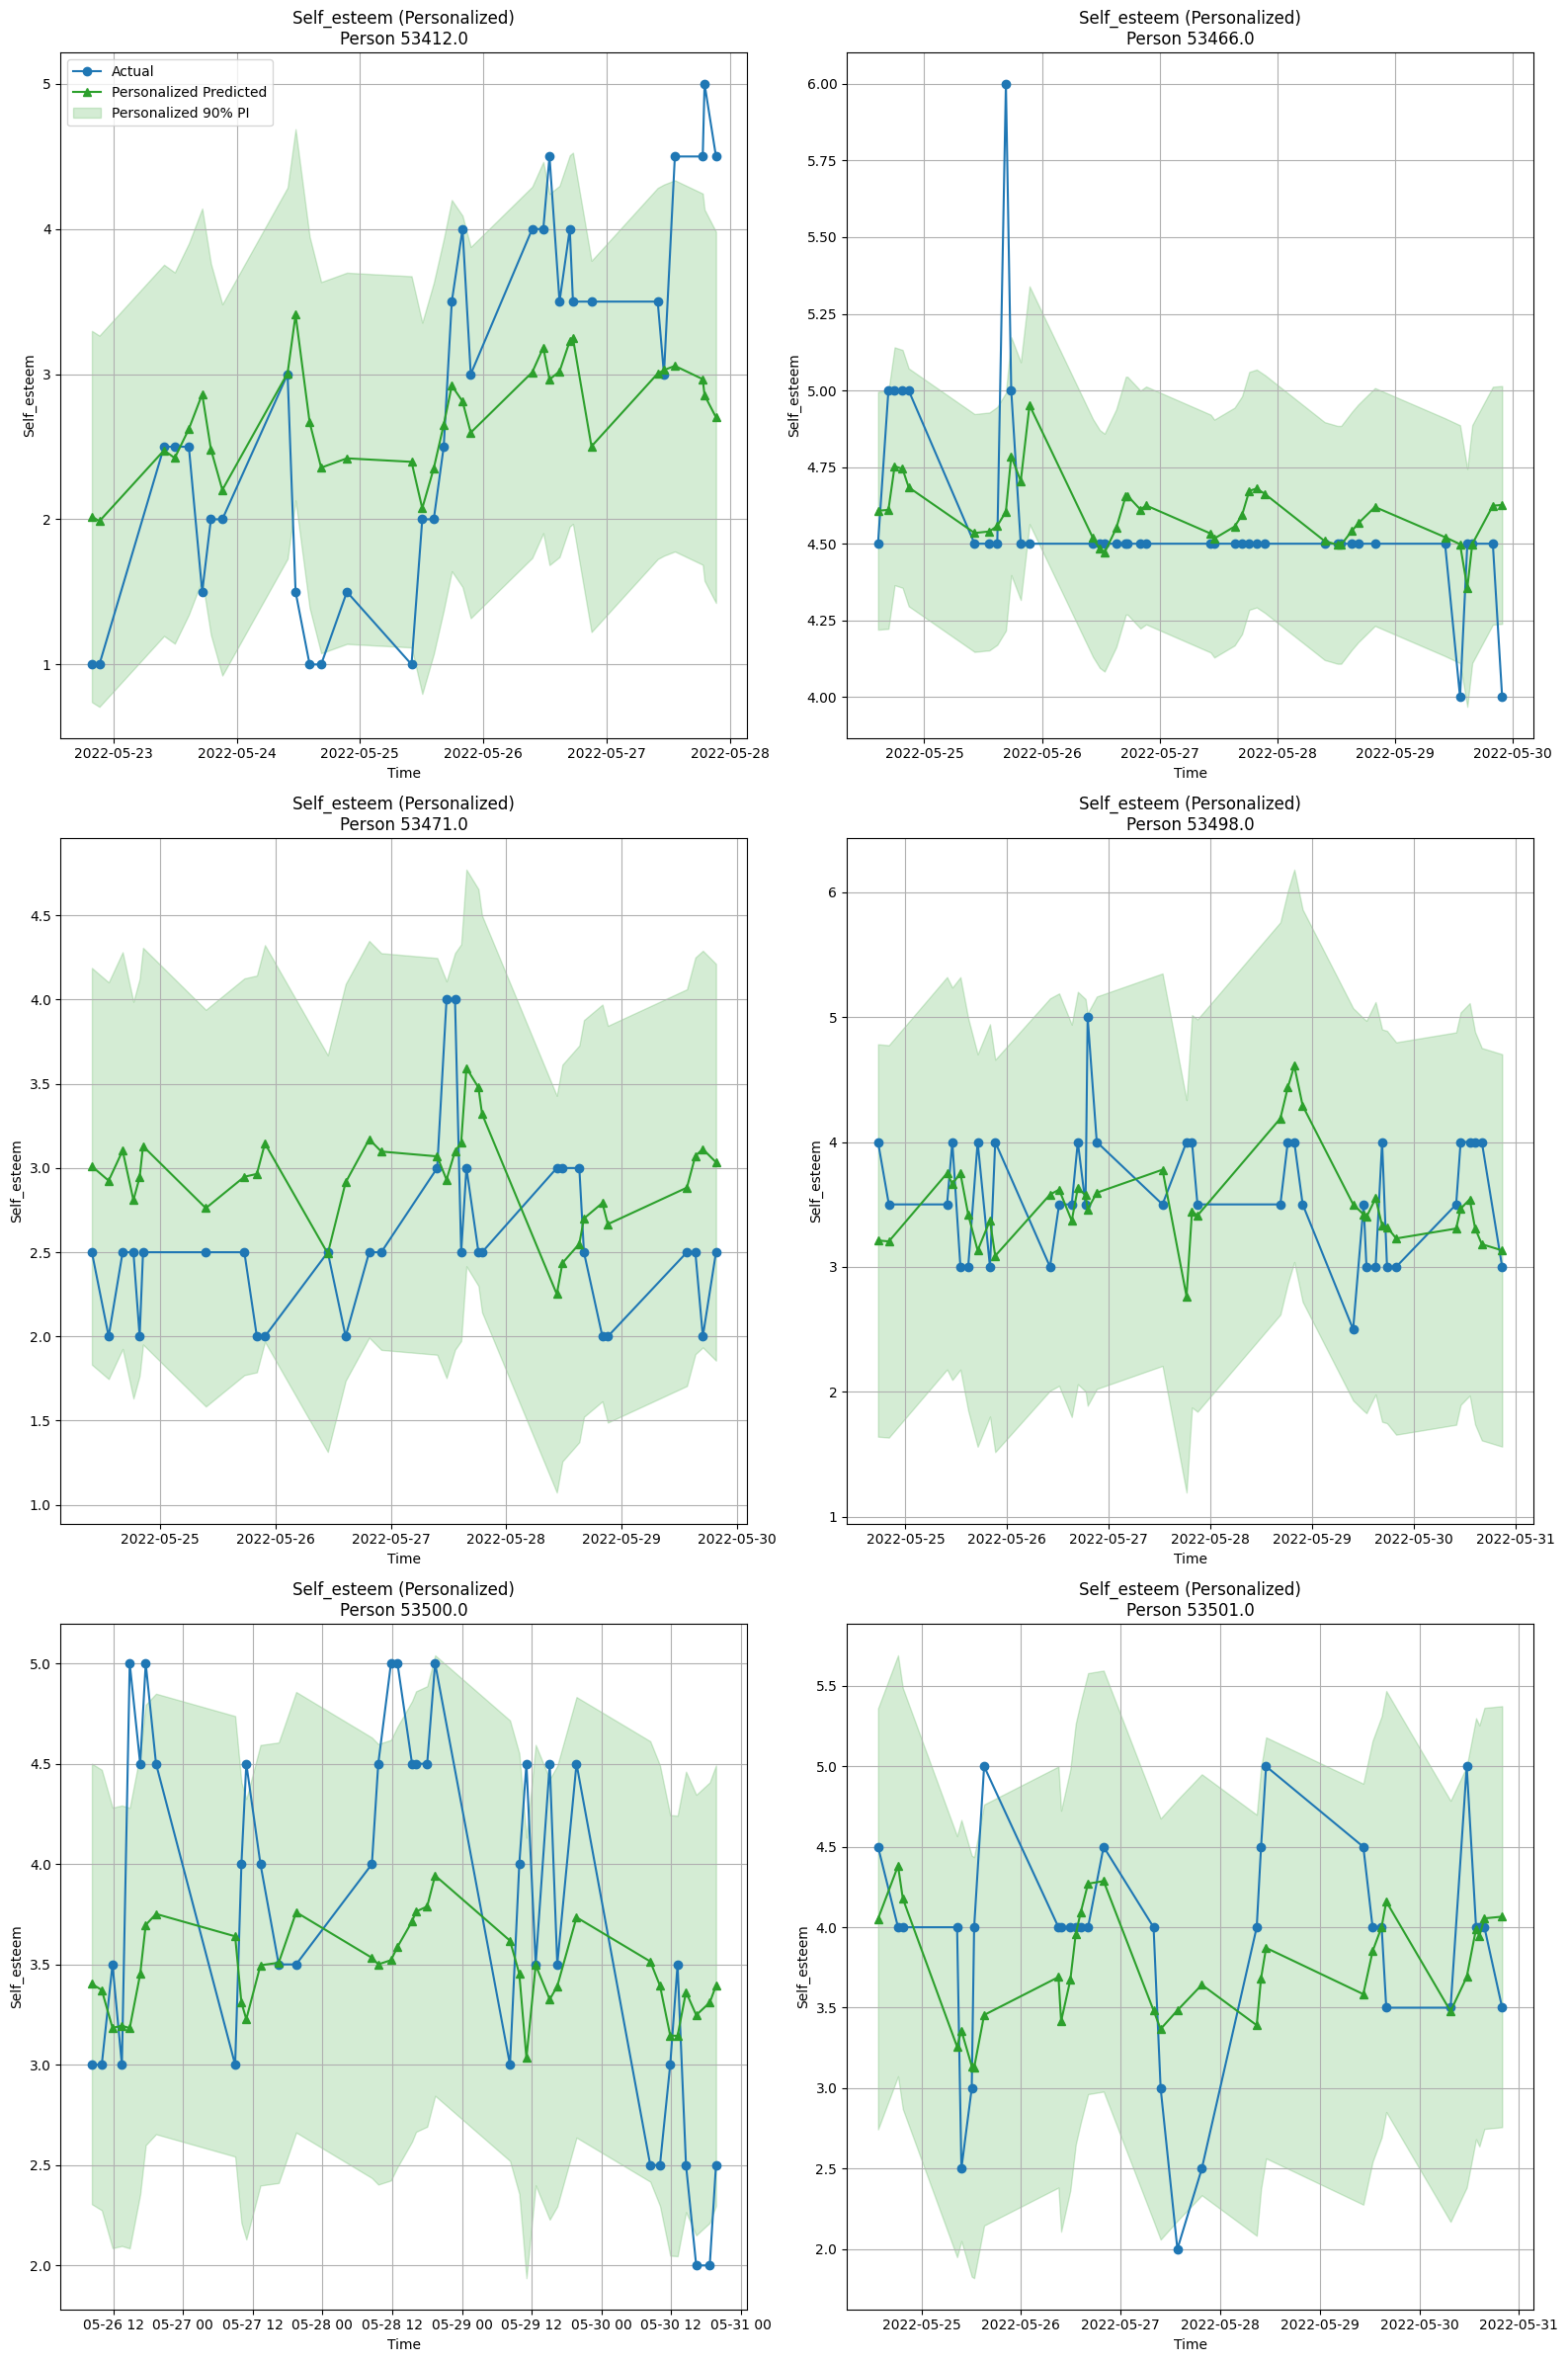

In [19]:
# PLOTTING (Group vs. Personalized)
import math
test_users = df_group["Name"].unique()
n_show = 6
n_cols = 2
n_rows = math.ceil(n_show / n_cols)

# Plot Group Model
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
axes = axes.flatten()
for i, pid in enumerate(test_users[:n_show]):
    ax = axes[i]
    sub_group = df_group[df_group["Name"] == pid].sort_values("datetime")
    ax.plot(sub_group["datetime"], sub_group["y_true"], "o-", color='C0', label="Actual")
    ax.plot(sub_group["datetime"], sub_group["y_pred"], "s-", color='C1', label="Group Predicted")
    ax.fill_between(sub_group["datetime"], sub_group["lower"], sub_group["upper"], color='C1', alpha=0.2, label="Group 90% PI")
    ax.set_title(f"{target_col} (Group Model)\nPerson {pid}")
    ax.set_xlabel("Time")
    ax.set_ylabel(target_col)
    ax.grid(True)
    if i == 0: ax.legend()
for ax in axes[len(test_users[:n_show]):]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()

# Plot Personalized Model
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows), sharex=False)
axes = axes.flatten()
for i, pid in enumerate(test_users[:n_show]):
    ax = axes[i]
    sub_person = df_personal[df_personal["Name"] == pid].sort_values("datetime")
    if not sub_person.empty:
        ax.plot(sub_person["datetime"], sub_person["y_true"], "o-", color='C0', label="Actual")
        ax.plot(sub_person["datetime"], sub_person["y_pred"], "^-", color='C2', label="Personalized Predicted")
        ax.fill_between(sub_person["datetime"], sub_person["lower"], sub_person["upper"], color='C2', alpha=0.2, label="Personalized 90% PI")
    ax.set_title(f"{target_col} (Personalized)\nPerson {pid}")
    ax.set_xlabel("Time")
    ax.set_ylabel(target_col)
    ax.grid(True)
    if i == 0: ax.legend()
for ax in axes[len(test_users[:n_show]):]:
    fig.delaxes(ax)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np

def empirical_coverage(y_true, lower, upper):
    return np.mean((y_true >= lower) & (y_true <= upper))

def avg_interval_width(lower, upper):
    return np.mean(upper - lower)

def get_coverage_curve(y_true, predict_intervals_fn, alphas):
    coverages = []
    widths = []
    for alpha in alphas:
        lower, upper = predict_intervals_fn(alpha)
        cov = empirical_coverage(y_true, lower, upper)
        width = avg_interval_width(lower, upper)
        coverages.append(cov)
        widths.append(width)
    return np.array(coverages), np.array(widths)

In [21]:
def mapie_intervals_fn(mapie_model, X):
    def inner(alpha):
        _, y_pis = mapie_model.predict(X, alpha=alpha)
        lower = y_pis[:, 0, 0] if y_pis.ndim == 3 else y_pis[:, 0]
        upper = y_pis[:, 1, 0] if y_pis.ndim == 3 else y_pis[:, 1]
        return lower, upper
    return inner

In [27]:
def enbpi_intervals_fn(model, X_test, X_calib, y_calib):
    def inner(alpha):
        model.alpha = alpha
        model.calibrate(X_calib, y_calib)
        return model.predict_interval(X_test)[1:]    # returns (lower, upper)
    return inner

In [23]:
def tree_cp_intervals_fn(yg_pred, test_nodes, calib_nodes, residuals, alpha):
    lower, upper = [], []
    for i, node in enumerate(test_nodes):
        mask = (calib_nodes == node)
        local_res = residuals[mask]
        if len(local_res) < 5:
            q = np.quantile(residuals, 1-alpha)
        else:
            q = np.quantile(local_res, 1-alpha)
        lower.append(yg_pred[i] - q)
        upper.append(yg_pred[i] + q)
    return np.array(lower), np.array(upper)

In [24]:
tree_fn = lambda alpha: tree_cp_intervals_fn(yg_pred, test_nodes_g, calib_nodes_g, residuals_g, alpha)

In [25]:
alphas = np.linspace(0.01, 0.99, 20)

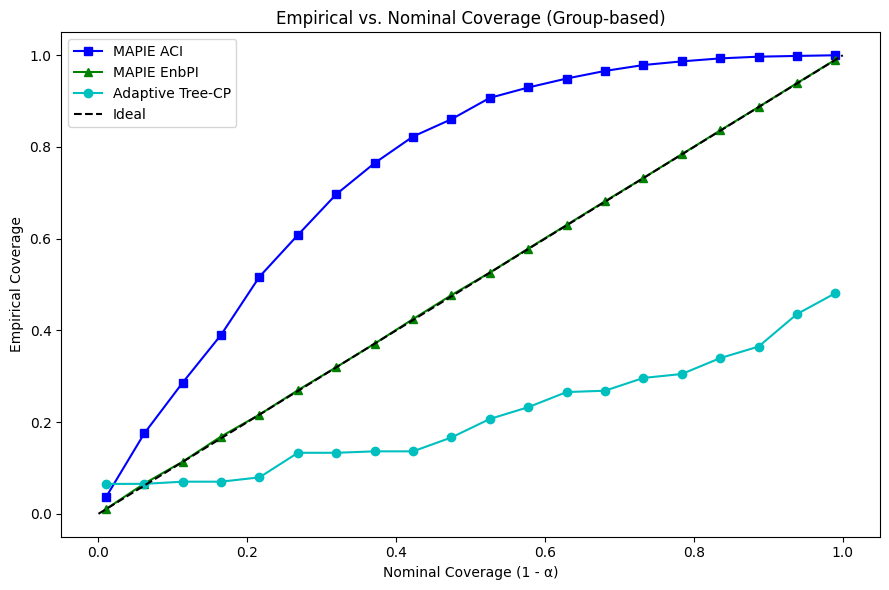

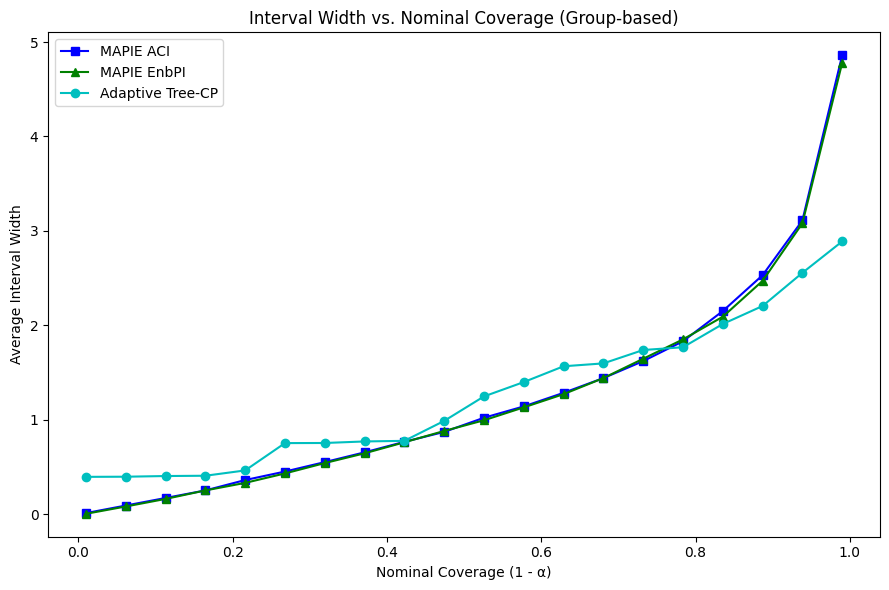

In [ ]:
plt.figure(figsize=(9,6))
plt.plot(1 - alphas, aci_curve, 'bs-', label="MAPIE ACI")
plt.plot(1 - alphas, enbpi_m_curve, 'g^-', label="MAPIE EnbPI")
plt.plot(1 - alphas, tree_curve, 'co-', label="Adaptive Tree-CP")
plt.plot([0,1], [0,1], 'k--', label="Ideal")
plt.xlabel("Nominal Coverage (1 - α)")
plt.ylabel("Empirical Coverage")
plt.title("Empirical vs. Nominal Coverage (Group-based)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
plt.plot(1 - alphas, aci_width, 'bs-', label="MAPIE ACI")
plt.plot(1 - alphas, enbpi_m_width, 'g^-', label="MAPIE EnbPI")
plt.plot(1 - alphas, tree_width, 'co-', label="Adaptive Tree-CP")
plt.xlabel("Nominal Coverage (1 - α)")
plt.ylabel("Average Interval Width")
plt.title("Interval Width vs. Nominal Coverage (Group-based)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import PredefinedSplit
from mapie.regression import MapieRegressor
from mapie.regression import MapieTimeSeriesRegressor as TimeSeriesRegressor
from mapie.conformity_scores import AbsoluteConformityScore
from sklearn.metrics import mean_absolute_error

# Load & feature‐engineering
csv_path = '/content/drive/My Drive/Colab_Notebooks/RGP2/Dataset.csv'
data = pd.read_csv(csv_path)
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'])
data = data.sort_values(['Name','datetime']).reset_index(drop=True)
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek
all_targets = ['PA','NA','Som_neg','Self_esteem','Enj_act','Enj_social',
               'Crave_Food','Crave_Other','In control','Concentrated',
               'Worried','Impulsivity']
drop_cols = ['Date','Time','Name','datetime'] + all_targets
FEATURE_COLS = data.drop(columns=drop_cols).select_dtypes(include=[np.number]).columns.tolist()
target_col = 'Worried'

# Build per‐person 60/20/20 splits ---
train_idx, calib_idx, test_idx = [], [], []
for name, grp in data.groupby('Name'):
    idx = grp.index.values
    m = len(idx)
    n_tr = math.floor(0.6*m)
    n_ca = math.floor(0.2*m)
    train_idx.extend(idx[:n_tr])
    calib_idx.extend(idx[n_tr:n_tr+n_ca])
    test_idx.extend(idx[n_tr+n_ca:])
train_df = data.loc[train_idx].reset_index(drop=True)
calib_df = data.loc[calib_idx].reset_index(drop=True)
test_df  = data.loc[test_idx].reset_index(drop=True)

def manual_aci_intervals(preds, truths, cal_res, alpha, gamma):
    q = np.quantile(cal_res, 1 - alpha)
    lo = np.empty_like(preds)
    up = np.empty_like(preds)
    for i, (yhat, ytrue) in enumerate(zip(preds, truths)):
        lo[i] = yhat - q
        up[i] = yhat + q
        miss = int(abs(ytrue - yhat) > q)
        q += gamma * (miss - alpha)
        q = max(q, 0.0)
    return lo, up

# Compare methods and collect metrics ---
alpha = 0.10
gamma_aci = 0.5
plot_ids = [10094, 43823, 43892, 56138.0]

results = []
for pid in plot_ids:
    # get person‐specific data
    df_tr = train_df[ train_df['Name']==pid ]
    df_ca = calib_df[ calib_df['Name']==pid ]
    df_te = test_df[  test_df['Name']==pid ]
    if df_tr.empty or df_ca.empty or df_te.empty:
        continue

    X_tr, y_tr = df_tr[FEATURE_COLS].values, df_tr['Worried'].values
    X_ca, y_ca = df_ca[FEATURE_COLS].values, df_ca['Worried'].values
    X_te, y_te = df_te[FEATURE_COLS].values, df_te['Worried'].values

    #  Split‐CP
    rf_cp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_cp.fit(X_tr, y_tr)
    mapie = MapieRegressor(rf_cp, method='plus', cv='prefit')
    mapie.fit(X_ca, y_ca)
    y_cp, pi_cp = mapie.predict(X_te, alpha=alpha)
    lo_cp, up_cp = pi_cp[:,0,0], pi_cp[:,1,0]

    #  Manual ACI
    rf_aci = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_aci.fit(X_tr, y_tr)
    cal_res = np.abs(y_ca - rf_aci.predict(X_ca))
    preds_aci = rf_aci.predict(X_te)
    lo_aci, up_aci = manual_aci_intervals(preds_aci, y_te, cal_res, alpha, gamma_aci)

    #  Personalized ENbPI
    X_enb = np.vstack([X_ca, X_te])
    y_enb_all = np.concatenate([y_ca, y_te])
    cv_enb = PredefinedSplit(test_fold=[-1]*len(y_ca) + [0]*len(y_te))
    enbpi = TimeSeriesRegressor(
        estimator=RandomForestRegressor(n_estimators=100, random_state=42),
        method='enbpi',
        agg_function='mean',
        conformity_score=AbsoluteConformityScore(sym=True),
        cv=cv_enb,
        n_jobs=-1
    )
    enbpi.fit(X_enb, y_enb_all)
    y_enb_full, pi_enb_full = enbpi.predict(X_enb, alpha=alpha)
    y_enb = y_enb_full[-len(y_te):]
    lo_enb = pi_enb_full[-len(y_te):,0,0]
    up_enb = pi_enb_full[-len(y_te):,1,0]

    # Personalized DT Calibration
    rf_p = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_p.fit(X_tr, y_tr)
    resid_p = np.abs(y_ca - rf_p.predict(X_ca))
    tree_p = DecisionTreeRegressor(min_samples_leaf=5, max_leaf_nodes=4, random_state=42)
    tree_p.fit(X_ca, resid_p)
    leaves_ca = tree_p.apply(X_ca)
    leaves_te = tree_p.apply(X_te)
    y_p = rf_p.predict(X_te)
    lo_p, up_p = [], []
    for j, leaf in enumerate(leaves_te):
        loc = resid_p[leaves_ca==leaf]
        q90 = np.quantile(loc,1-alpha) if len(loc)>=3 else np.quantile(resid_p,1-alpha)
        lo_p.append(y_p[j] - q90)
        up_p.append(y_p[j] + q90)
    lo_p, up_p = np.array(lo_p), np.array(up_p)

    # compute metrics for each method
    def metrics(y_true, y_pred, lo, up):
        return (
            mean_absolute_error(y_true, y_pred),
            np.mean((y_true>=lo)&(y_true<=up)),
            np.mean(up - lo)
        )

    for method, y_pred, lo, up in [
        ('Split-CP', y_cp, lo_cp, up_cp),
        ('ACI',      preds_aci, lo_aci, up_aci),
        ('ENbPI',    y_enb,     lo_enb, up_enb),
        ('DT-Cal',   y_p,       lo_p,    up_p),
    ]:
        mae, cov, wid = metrics(y_te, y_pred, lo, up)
        results.append({
            'Person': pid,
            'Method': method,
            'MAE': mae,
            'Coverage': cov,
            'Width': wid
        })

#  Display comparison table
df_metrics = pd.DataFrame(results)
print(df_metrics.pivot(index='Person', columns='Method', values=['Coverage','Width']))

         Coverage                                   Width                  \
Method        ACI    DT-Cal     ENbPI  Split-CP       ACI    DT-Cal ENbPI   
Person                                                                      
10094.0  0.870968  0.741935  0.935484  0.903226  6.533118  4.555900  4.00   
43823.0  0.933333  0.933333  0.933333  0.966667  5.256800  6.009413  5.28   
43892.0  0.920000  0.920000  0.960000  0.960000  4.429333  3.844507  5.34   
56138.0  0.900000  0.800000  0.925000  0.975000  5.547400  5.087657  5.52   

                   
Method   Split-CP  
Person             
10094.0  6.000000  
43823.0  6.553000  
43892.0  4.691667  
56138.0  5.900000  


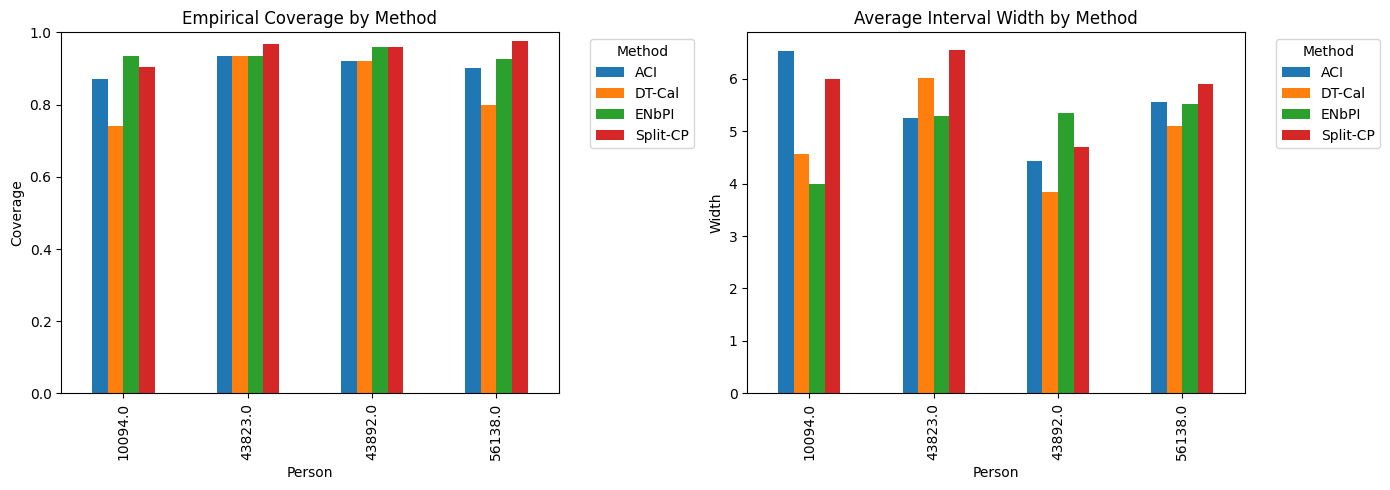

In [ ]:
import matplotlib.pyplot as plt


cov_df = df_metrics.pivot(index='Person', columns='Method', values='Coverage')
wid_df = df_metrics.pivot(index='Person', columns='Method', values='Width')

# Plot side‐by‐side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

# Empirical coverage
cov_df.plot(kind='bar', ax=ax1)
ax1.set_title('Empirical Coverage by Method')
ax1.set_ylabel('Coverage')
ax1.set_ylim(0, 1)
ax1.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

# Interval width
wid_df.plot(kind='bar', ax=ax2)
ax2.set_title('Average Interval Width by Method')
ax2.set_ylabel('Width')
ax2.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()